# Quantization Troubleshooting with the Model Compression Toolkit (MCT) Using the XQuant Extension Tool (Judgeable Troubleshooting)

[Run this tutorial in Google Colab](https://colab.research.google.com/github/SonySemiconductorSolutions/mct-model-optimization/blob/main/tutorials/notebooks/mct_features_notebooks/pytorch/example_pytorch_XQuant_Extension_Tool.ipynb)

## Overview
This notebook provides practical guidance for improving the quality of Post-Training Quantization for PyTorch models using the XQuant Extension Tool. 
It computes the error for each layer by comparing the floating-point model and the quantized model, and combines these results with the quantization log. The analysis is presented as a report that highlights the causes of detected errors and suggests appropriate corrective actions for each.

General troubleshooting actions are listed [here](https://colab.research.google.com/github/SonySemiconductorSolutions/mct-model-optimization/blob/main/tutorials/notebooks/mct_features_notebooks/pytorch/example_pytorch_XQuant_Extension_Tool_General.ipynb).

## Summary
We will cover the following steps:

1. Load a pre-trained MobileNetV3 model.
2. Perform Post-Training Quantization using MCT (no correction).
3. Use the XQuant Extension Tool
   - Understanding the Quantization Error Graph
   - Quantization Troubleshooting for MCT  
4. Judgeable Troubleshooting
   - Outlier Removal
5. Conclusion

## Setup
Install the relevant packages:

In [ ]:
!pip install torch==2.6.0 torchvision==0.21.0

import torch
from torch.utils.data import DataLoader
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights
from torchvision.datasets import ImageNet
import numpy as np
import random
import model_compression_toolkit as mct
from tqdm import tqdm
import os
from functools import partial
from model_compression_toolkit.xquant import XQuantConfig
from model_compression_toolkit.xquant import xquant_report_troubleshoot_pytorch_experimental

## MobileNet V3 Setting

In [ ]:
weights = MobileNet_V3_Large_Weights.IMAGENET1K_V2
float_model = mobilenet_v3_large(weights=weights)

## Representative Dataset

In [ ]:
if not os.path.isdir('imagenet'):
    !mkdir imagenet
    !wget -P imagenet https://image-net.org/data/ILSVRC/2012/ILSVRC2012_devkit_t12.tar.gz
    !wget -P imagenet https://image-net.org/data/ILSVRC/2012/ILSVRC2012_img_val.tar

dataset_path = './imagenet'
dataset = ImageNet(root=dataset_path, split='val', transform=weights.transforms())
batch_size = 16
n_iter = 10

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
def random_reset():
    seed = 0

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

    def seed_worker(worker_id):
        worker_seed = torch.initial_seed() % 2**32
        np.random.seed(worker_seed)
        random.seed(worker_seed)

    g = torch.Generator()
    g.manual_seed(seed)

    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, worker_init_fn=seed_worker, generator=g)

    return dataloader

In [ ]:
def representative_dataset_gen():
    dataloader_iter = iter(dataloader)
    for _ in range(n_iter):
        yield [next(dataloader_iter)[0]]

## Define a Random Data Generator
For demonstration purposes, we will use a random dataset generator to create both the representative dataset and the validation dataset. This will allow us to simulate data for quantization and validation without using an actual dataset.

In [ ]:
# Function to generate random data. If use_labels is True, it yields data with labels;
# otherwise, it yields only data.
def random_data_gen(shape=(3, 224, 224), use_labels=False, batch_size=2, num_iter=2):
    if use_labels:
        for _ in range(num_iter):
            yield [[torch.randn(batch_size, *shape)], torch.randn(batch_size)]
    else:
        for _ in range(num_iter):
            yield [torch.randn(batch_size, *shape)]

## Evaluation Function

In [ ]:
def evaluate(model, testloader):
    """
    Evaluate a model using a test loader.
    """
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for data in tqdm(testloader):
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc = (100 * correct / total)
    print('Accuracy: %.2f%%' % val_acc)
    return val_acc


## Perform Post-Training Quantization using MCT (no correction)

In [ ]:
# Get a FrameworkQuantizationCapabilities object that models the hardware platform for the quantized model inference. 
target_platform_cap = mct.get_target_platform_capabilities_sdsp(sdsp_version='3.14')
configuration = mct.core.CoreConfig()
dataloader = random_reset()

# Post-Training Quantization using MCT
quantized_model, _ = mct.ptq.pytorch_post_training_quantization(in_module=float_model,
                                                                representative_data_gen=representative_dataset_gen,
                                                                core_config = configuration,
                                                                target_platform_capabilities=target_platform_cap
                                                                )


## Model Evaluation

In [ ]:
val_dataloader = DataLoader(dataset, batch_size=50, shuffle=False, num_workers=16, pin_memory=True)
evaluate(float_model, val_dataloader)
evaluate(quantized_model, val_dataloader)

The quantized_model accuracy was 73%. We will improve this.

## Use the XQuant Extension Tool

In [ ]:
# Define the validation dataset and XQuant configuration, including custom similarity metrics.
validation_dataset = partial(random_data_gen, use_labels=True)
xquant_config = XQuantConfig(report_dir='./logs', custom_similarity_metrics={'mae': lambda x,y: torch.nn.L1Loss()(x,y).item()})

# Generate the XQuant report comparing the float model and the quantized model using the
# representative and validation datasets.
xquant_report_troubleshoot_pytorch_experimental(float_model,
                                                quantized_model,
                                                random_data_gen,
                                                validation_dataset,
                                                xquant_config
                                                )

### Understanding the Quantization Error Graph

Six quantization error graphs will be generated in the directory specified by report_dir in XQuantConfig.

These graphs display three metrics — MSE, cosine similarity, and SQNR — for two datasets: the representative dataset and the validation dataset.

The quantization error indicates the difference in each layer’s output between the floating-point model and the quantized model.

Each layer’s quantization error is compared with threshold_quantize_error to identify layers that exhibit significant behavioral changes after quantization.

As an example, the figure below shows an output graph computed using the “mse” metric with the representative dataset. A default threshold value of 0.1 is set, and layers exceeding this threshold are marked with red circles. In addition, the corresponding layer names on the X-axis are highlighted in red.

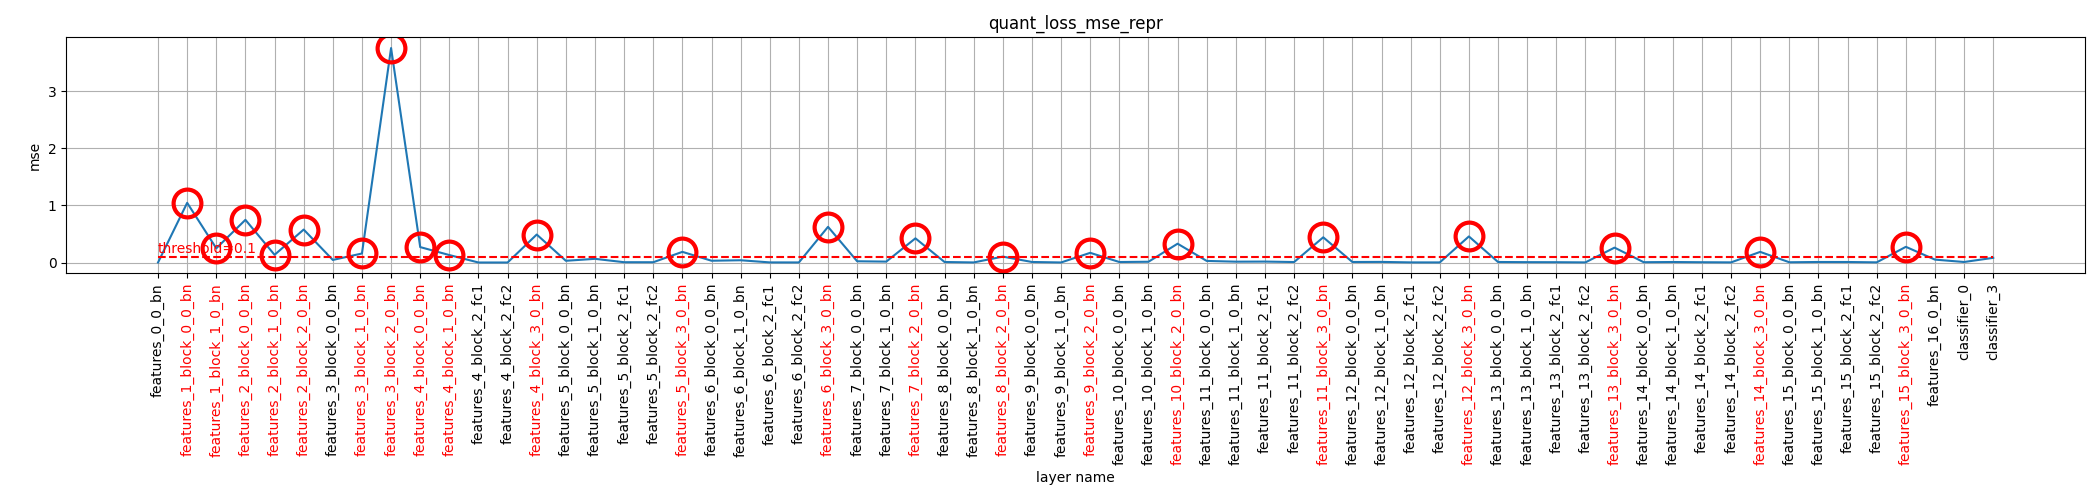

- X-axis: Layer names (layers identified as degraded are highlighted in red)
- Y-axis: Quantization error
- Red dashed line: Threshold for accuracy degradation, as defined in XQuantConfig
- Red circle: Layers judged to have degraded accuracy


From the graph, we can see that the layer "features_1", "features_2", "features_3" etc is deteriorating.

### Quantization Troubleshooting for MCT

The Model Compression Toolkit (MCT) offers numerous functionalities to compress neural networks with minimal accuracy loss. However, in some cases, the compressed model may experience a significant decrease in accuracy.

This lost accuracy can often be recovered by adjusting the quantization configuration or setup.
Listed below are a series of steps designed to help you recover any accuracy lost during compression with MCT. Some steps may apply to your model, while others may not.

The XQuant Extension Tool automatically detects potential issues and displays the relevant warning messages in the console. Please refer to the corresponding troubleshooting guide and modify the settings as needed.

See [Troubleshooting Manual](https://sonysemiconductorsolutions.github.io/mct-model-optimization/docs_troubleshoot/index.html)


# Judgeable Troubleshoot
## Outlier Removal
Outlier activations in your model's quantization layers, or those with too broad a distribution, can lead to poor quantization accuracy.

You can see whether your activation tensors have outliers and how spread out their distributions are by visualizing the histograms (see below) generated in the directory specified by XQuantConfig's report_dir.

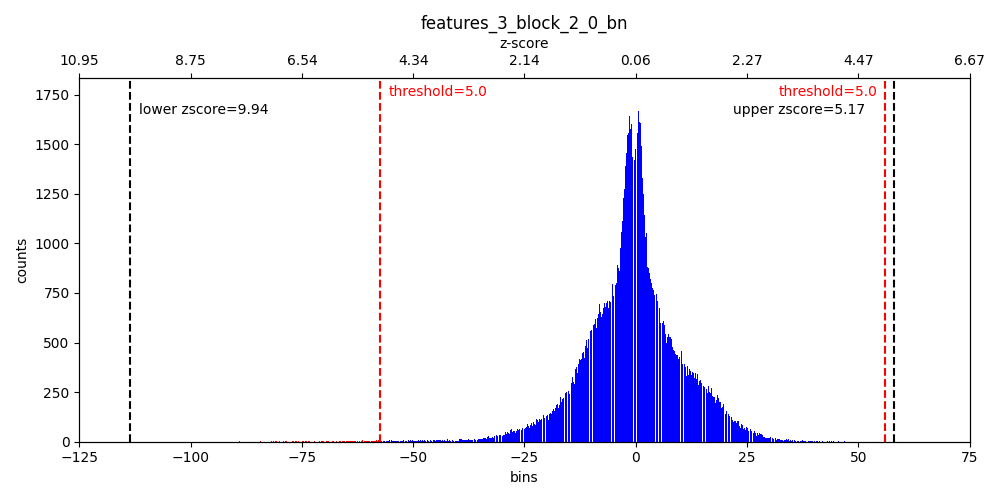

See [Troubleshooting Documentation>>Outlier Removal](https://sonysemiconductorsolutions.github.io/mct-model-optimization/docs_troubleshoot/troubleshoots/outlier_removal.html#ug-outlier-removal)

In [ ]:
# Set z_threshold to 25 in the XQuant configuration and re-run the quantization process.
outlier_arg = [5, 10, 15, 20, 25, 30]
results = []
for outlier in outlier_arg:
    print(f"Z-Threshold: {outlier}")
    configuration = mct.core.CoreConfig(mct.core.QuantizationConfig(z_threshold=outlier))
    dataloader = random_reset()

    # Post-Training Quantization using MCT
    quantized_model, _ = mct.ptq.pytorch_post_training_quantization(in_module=float_model,
                                                                    representative_data_gen=representative_dataset_gen,
                                                                    core_config = configuration,
                                                                    target_platform_capabilities=target_platform_cap
                                                                    )
    
    val_dataloader = DataLoader(dataset, batch_size=50, shuffle=False, num_workers=16, pin_memory=True)
    val_acc = evaluate(quantized_model, val_dataloader)
    results.append(val_acc)

In [ ]:
# Print results after each iteration
for outlier, acc in zip(outlier_arg, results):
    print(f"Z-Threshold: {outlier}, Accuracy: {acc:.2f}%")

## Conclusion
Through this XQuant analysis, the accuracy improved by 0.14%.
By using this technique, you can improve the accuracy of your model with the XQuant Extension Tool.

To see general Troubleshooting actions and practical guidance to improve the post-training quantization quality of your PyTorch models, check out [the notebook](https://colab.research.google.com/github/SonySemiconductorSolutions/mct-model-optimization/blob/main/tutorials/notebooks/mct_features_notebooks/pytorch/example_pytorch_XQuant_Extension_Tool_General.ipynb). 

## Copyrights
Copyright 2026 Sony Semiconductor Solutions, Inc. All rights reserved.

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

    http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
